In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
df = pd.read_csv('height-weight.csv')

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


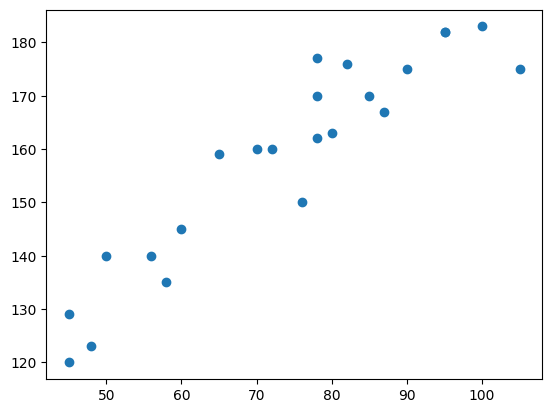

In [6]:
plt.scatter(df['Weight'], df['Height'])

In [7]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [8]:
# Independent feature should be a type of dataframe or 2d array
# X = df['Weight'] => this is of type series
X = df[['Weight']]
y = df['Height']  # this can be in series or 1d array
print(type(X))
type(y)

<class 'pandas.DataFrame'>


pandas.Series

In [9]:
# Train Test split

from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25, random_state=42)

In [11]:
X_train.shape

(17, 1)

In [12]:
# Standardization
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [14]:
X_test = scaler.transform(X_test)

In [15]:
# Apply Machine Learning Algorithm
from sklearn.linear_model import LinearRegression

In [16]:
regression = LinearRegression(n_jobs=-1) # n_jobs makes the model use all the cores in the system.

In [17]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
print("Coefficient or slope :", regression.coef_ )
print("Intercept :", regression.intercept_)

Coefficient or slope : [17.2982057]
Intercept : 156.47058823529412


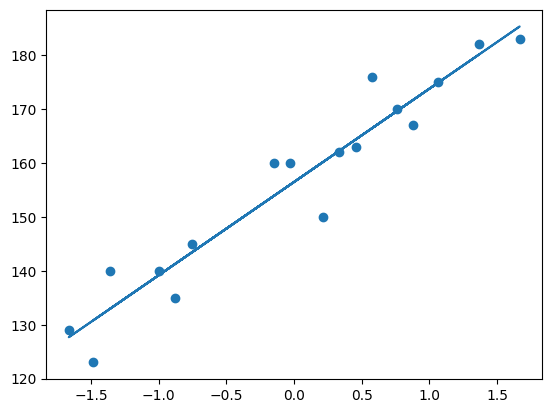

In [19]:
# Plotting training data and Best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))

In [20]:
# Prediction for test data
y_pred = regression.predict(X_test)

In [21]:
# Preformance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [22]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


In [23]:
# R2 Score
from sklearn.metrics import r2_score

In [24]:
score = r2_score(y_test, y_pred)
print(score)

0.7360826717981276


In [25]:
adj_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print(adj_r2)

0.6701033397476595


In [26]:
# OLS Linear Regression
import statsmodels.api as sm

In [27]:
model=sm.OLS(y_train,X_train).fit()

In [28]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [29]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 24 Mar 2026   Prob (F-statistic):                       0.664
Time:                        22:48:24   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [30]:
# Prediction for new data
regression.predict(scaler.transform([[72]]))

c:\Users\gupta\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])